## Loading in the cbs dataset

In [1]:
import pandas as pd

def load_and_clean_csv(path):
    df_raw = pd.read_csv(path, header=None)
    df_split = df_raw[0].str.split(";", expand=True)
    header_index = df_split[df_split[0].str.contains("Beroep", na=False)].index[0]
    df_split.columns = df_split.iloc[header_index]
    df_cleaned = df_split[(header_index + 1):].reset_index(drop=True)
    df_cleaned = df_cleaned.drop(df_cleaned.index[-1])
    df_cleaned.columns = ["Beroep", "Totaal", "Mannen", "Vrouwen"]
    df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)
    df_cleaned["Totaal"] = pd.to_numeric(df_cleaned["Totaal"], errors='coerce')
    df_cleaned["Mannen"] = pd.to_numeric(df_cleaned["Mannen"], errors='coerce')
    df_cleaned["Vrouwen"] = pd.to_numeric(df_cleaned["Vrouwen"], errors='coerce')
    df_cleaned["%Vrouwen"] = (df_cleaned["Vrouwen"] / df_cleaned["Totaal"]) * 100
    return df_cleaned

# Load both datasets
df1 = load_and_clean_csv("/Users/jonasklein/Downloads/Werkzame_beroepsbevolking__beroep_09042025_170847.csv")
df2 = load_and_clean_csv("/Users/jonasklein/Downloads/Werkzame_beroepsbevolking__beroep_09042025_171307.csv")

# Combine them into one DataFrame
df_combined = pd.concat([df1, df2], ignore_index=True)

# Order the DataFrame on %Vrouwen
df_combined = df_combined.sort_values(by="%Vrouwen", ascending=False)

# Show the combined DataFrame
df_combined

/var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/ipykernel_67817/3931073154.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)
/var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/ipykernel_67817/3931073154.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df_cleaned.applymap(lambda x: x.strip('" ').strip() if isinstance(x, str) else x)


,Beroep,Totaal,Mannen,Vrouwen,%Vrouwen
92,1032 Apothekersassistenten,28,1,26,92.857143
94,1034 Medisch praktijkassistenten,93,7,86,92.473118
29,0432 Secretaresses,36,3,33,91.666667
97,1051 Verzorgenden,267,26,241,90.262172
101,1114 Kappers en schoonheidsspecialisten,61,6,55,90.163934
...,...,...,...,...,...
68,0744 Machinemonteurs,57,56,2,3.508772
65,0741 Metaalbewerkers en constructiewe.,31,30,1,3.225806
63,0734 Loodgieters en pijpfitters,38,37,1,2.631579
62,0733 Bouwarbeiders afbouw,42,41,1,2.380952


In [343]:
# Save the combined DataFrame to a CSV file
df_combined.to_csv("../out/combined_beroepsbevolking.csv", index=False)

## Manually renaming columns and keeping informative professions for sentence creation

In [163]:
from collections import defaultdict

cleaned_dict_man = defaultdict(list)

entries = [
    ("0522 Managers verkoop en marketing", "Manager"),
    ("0911 Land- en bosbouwers", "Landbouwer"),
    ("0911 Land- en bosbouwers", "Bosbouwer"),
    ("0435 Transportplanners en logistiek m.", "Transportplanner"),
    ("0435 Transportplanners en logistiek m.", "Logistiek medewerker"),
    ("0633 Beveiligingspersoneel", "Beveiligingsmedewerker"),

    ("0511 Algemeen directeuren", "Directeur"),
    ("0511 Algemeen directeuren", "Directrice"),

    ("0551 Managers z.n.d.", "Manager"),
    ("0821 Gebruikersondersteuning ICT", "ICT'er"),
    ("0536 Managers gespecialiseerde dienst.", "Manager"),
    ("0822 Radio- en televisietechnici", "Technicus"),
    ("0712 Ingenieurs (geen elektrotechniek)", "Ingenieur"),
    ("0721 Technici bouwkunde en natuur", "Technicus"),
    ("0811 Software- en applicatieontwikkel.", "Softwareontwikkelaar"),
    ("0811 Software- en applicatieontwikkel.", "Applicatieontwikkelaar"),
    ("0912 Hoveniers, tuinders en kwekers", "Hovenier"),
    ("0912 Hoveniers, tuinders en kwekers", "Tuinder"),
    ("0912 Hoveniers, tuinders en kwekers", "Kweker"),
    ("0634 Militaire beroepen", "Militair"),
    ("1212 Chauffeurs auto's, taxi's en bes.", "Chauffeur"),
    ("0533 Managers ICT", "Manager"),
    ("1213 Buschauffeurs en trambestuurders", "Chauffeur"),
    ("0532 Managers logistiek", "Manager"),
    ("0531 Managers productie", "Manager"),
    ("1211 Dekofficieren en piloten", "Dekofficier"),
    ("1211 Dekofficieren en piloten", "Piloot"),
    ("0722 Productieleiders industrie en bouw", "Productieleider"),
    ("0735 Schilders en metaalspuiters", "Schilder"),
    ("0735 Schilders en metaalspuiters", "Metaalspuiter"),
    ("0713 Elektrotechnisch ingenieurs", "Ingenieur"),
    ("0743 Automonteurs", "Monteur"),
    ("1214 Vrachtwagenchauffeurs", "Vrachtwagenchauffeur"),
    ("0723 Procesoperators", "Procesoperator"),
    ("0731 Bouwarbeiders ruwbouw", "Bouwarbeider"),
    ("0761 Elektriciens en elektronicamonteurs", "Elektricien"),
    ("0742 Lassers en plaatwerkers", "Lasser"),
    ("0744 Machinemonteurs", "Monteur"),
    ("0741 Metaalbewerkers en constructiewe.", "Metaalbewerker"),
    ("0741 Metaalbewerkers en constructiewe.", "Constructiewerker"),
    ("0734 Loodgieters en pijpfitters", "Loodgieter"),
    ("0733 Bouwarbeiders afbouw", "Bouwarbeider"),
    #("0732 Timmerlieden", "Timmerman"),
]

print(entries)

for key, value in entries:
    cleaned_dict_man[key].append(value)

# Unique values across all categories
unique_values = set(v for values in cleaned_dict_man.values() for v in values)
print(unique_values)
print(len(unique_values))


[('0522 Managers verkoop en marketing', 'Manager'), ('0911 Land- en bosbouwers', 'Landbouwer'), ('0911 Land- en bosbouwers', 'Bosbouwer'), ('0435 Transportplanners en logistiek m.', 'Transportplanner'), ('0435 Transportplanners en logistiek m.', 'Logistiek medewerker'), ('0633 Beveiligingspersoneel', 'Beveiligingsmedewerker'), ('0511 Algemeen directeuren', 'Directeur'), ('0511 Algemeen directeuren', 'Directrice'), ('0551 Managers z.n.d.', 'Manager'), ('0821 Gebruikersondersteuning ICT', "ICT'er"), ('0536 Managers gespecialiseerde dienst.', 'Manager'), ('0822 Radio- en televisietechnici', 'Technicus'), ('0712 Ingenieurs (geen elektrotechniek)', 'Ingenieur'), ('0721 Technici bouwkunde en natuur', 'Technicus'), ('0811 Software- en applicatieontwikkel.', 'Softwareontwikkelaar'), ('0811 Software- en applicatieontwikkel.', 'Applicatieontwikkelaar'), ('0912 Hoveniers, tuinders en kwekers', 'Hovenier'), ('0912 Hoveniers, tuinders en kwekers', 'Tuinder'), ('0912 Hoveniers, tuinders en kwekers',

In [164]:
from collections import defaultdict

cleaned_dict_woman = defaultdict(list)

entries = [
    ("1032 Apothekersassistenten", "Apothekerassistent"),
    ("1032 Apothekersassistenten", "Apothekerassistente"),

    ("1034 Medisch praktijkassistenten", "Praktijkassistent"),
    ("1034 Medisch praktijkassistenten", "Praktijkassistente"),

    ("0432 Secretaresses", "Secretaresse"),
    ("0423 directiesecretaresses", "Secretaresse"),

    ("1051 Verzorgenden", "Verzorgende"),
    ("1051 Verzorgenden", "Verzorgster"),

    ("1114 Kappers en schoonheidsspecialisten", "Kapper"),
    ("1114 Kappers en schoonheidsspecialisten", "Kapster"),

    ("1114 Kappers en schoonheidsspecialisten", "Schoonheidsspecialist"),
    ("1114 Kappers en schoonheidsspecialisten", "Schoonheidsspecialiste"),

    ("1012 Gespecialiseerd verpleegkundigen", "Verpleegkundige"),
    ("1012 Gespecialiseerd verpleegkundigen", "Verpleegster"),

    #("0131 Leidsters kinderopvang en onderw...", "Leidster"),
    ("0131 Leidsters kinderopvang en onderw...", "Onderwijzer"),
    ("0131 Leidsters kinderopvang en onderw...", "Onderwijzeres"),

    ("1033 Verpleegkundigen (mbo)", "Verpleegkundige"),
    ("1033 Verpleegkundigen (mbo)", "Verpleegster"),

    ("0114 Leerkrachten basisonderwijs", "Leerkracht"),

    ("1022 Psychologen en sociologen", "Psycholoog"),
    ("1022 Psychologen en sociologen", "Psychologe"),

    ("1022 Psychologen en sociologen", "Socioloog"),
    ("1022 Psychologen en sociologen", "Sociologe"),

    ("0333 Kassamedewerkers", "Kassamedewerker"),
    ("0333 Kassamedewerkers", "Kassière"),

    ("1021 Maatschappelijk werkers", "Maatschappelijk werker"),
    ("1021 Maatschappelijk werkers", "Maatschappelijk werkster"),

    ("0434 Boekhoudkundig medewerkers", "Boekhoudkundige"),
    ("0434 Boekhoudkundig medewerkers", "Boekhoudster"),
    ("0434 Boekhoudkundig medewerkers", "Boekhouder"),

    ("1121 Schoonmakers", "Schoonmaker"),
    ("1121 Schoonmakers", "Schoonmaakster"),

    ("1013 Fysiotherapeuten", "Fysiotherapeut"),
    ("1013 Fysiotherapeuten", "Fysiotherapeute"),

    ("1041 Sociaal werkers, groeps- en woon.", "Sociaal werker"),
    ("1041 Sociaal werkers, groeps- en woon.", "Sociaal werkster"),

    ("1031 laboranten", "Laborant"),
    ("1031 laboranten", "Laborante"),

    ("0431 Administratief medewerkers", "Administratief medewerker"),
    ("0431 Administratief medewerkers", "Administratief medewerkster"),

    ("0433 Receptionisten en telefonisten", "Receptionist"),
    ("0433 Receptionisten en telefonisten", "Receptioniste"),

    ("0433 Receptionisten en telefonisten", "Telefonist"),
    ("0433 Receptionisten en telefonisten", "Telefoniste"),

    ("0115 Onderwijskundigen en overige doc...", "Onderwijskundige"),

    ("0115 Onderwijskundigen en overige doc...", "Docent"),
    ("0115 Onderwijskundigen en overige doc...", "Docente"),

    ("0332 Verkoopmedewerkers detailhandel", "Verkoopmedewerker"),
    ("0332 Verkoopmedewerkers detailhandel", "Verkoopster"),

    ("1111 Reisbegeleiders", "Reisbegeleider"),
    ("1111 Reisbegeleiders", "Reisbegeleidster"),

    ("0415 Specialisten personeels- en loop.", "HR-medewerker"),
    ("0415 Specialisten personeels- en loop.", "HR-medewerkster"),

    ("0415 Specialisten personeels- en loop.", "Loopbaanadviseur"),
    ("0415 Specialisten personeels- en loop.", "Loopbaanadviseuse"),

    ("0415 Specialisten personeels- en loop.", "Loopbaanbegeleider"),
    ("0415 Specialisten personeels- en loop.", "Loopbaanbegeleidster"),

    ("1113 Kelners en barpersoneel", "Barmedewerker"),
    ("1113 Kelners en barpersoneel", "Barmedewerkster"),

    ("0211 Bibliothecarissen en conservatoren", "Bibliothecaris"),
    ("0211 Bibliothecarissen en conservatoren", "Bibliothecaresse"),

    ("0211 Bibliothecarissen en conservatoren", "Conservator"),
]

for key, value in entries:
    cleaned_dict_woman[key].append(value)

# All job titles (unique) for women
unique_titles = set(v for values in cleaned_dict_woman.values() for v in values)
print(unique_titles)
print(len(unique_titles))

{'Verkoopmedewerker', 'Verzorgende', 'Kassamedewerker', 'Sociaal werkster', 'Laborant', 'Psychologe', 'Laborante', 'Praktijkassistent', 'Loopbaanadviseur', 'Loopbaanadviseuse', 'Onderwijskundige', 'Telefonist', 'Barmedewerkster', 'Conservator', 'Kapper', 'Verpleegster', 'Secretaresse', 'Administratief medewerker', 'Docent', 'Verzorgster', 'Psycholoog', 'Apothekerassistente', 'Sociologe', 'HR-medewerker', 'Schoonheidsspecialiste', 'Boekhouder', 'Onderwijzer', 'Apothekerassistent', 'Socioloog', 'Verpleegkundige', 'Onderwijzeres', 'Leerkracht', 'Schoonmaker', 'Docente', 'Bibliothecaris', 'Praktijkassistente', 'Telefoniste', 'Boekhoudster', 'Schoonmaakster', 'Receptioniste', 'Barmedewerker', 'Kassière', 'Fysiotherapeute', 'Sociaal werker', 'Loopbaanbegeleider', 'Bibliothecaresse', 'Loopbaanbegeleidster', 'Maatschappelijk werkster', 'Administratief medewerkster', 'Receptionist', 'Verkoopster', 'Schoonheidsspecialist', 'Reisbegeleidster', 'Boekhoudkundige', 'HR-medewerkster', 'Kapster', 'Rei

In [ ]:
import pandas as pd
from collections import defaultdict

# Load the CSV file
df_dutch_professions = pd.read_csv("../out/combined_beroepsbevolking.csv")

# Combine them
combined_cleaned_dict = defaultdict(list)
for d in [cleaned_dict_man, cleaned_dict_woman]:
    for k, v_list in d.items():
        combined_cleaned_dict[k].extend(v_list)

df_dutch_professions['Beroep'] = df_dutch_professions['Beroep'].str.strip().str.lower()
combined_cleaned_dict = {k.strip().lower(): [v.strip().lower() for v in vs] for k, vs in combined_cleaned_dict.items()}

# Clean duplicates from values
for k in combined_cleaned_dict:
    combined_cleaned_dict[k] = list(set(combined_cleaned_dict[k]))

# Expand DataFrame using the lookup
expanded_rows = []

for _, row in df_dutch_professions.iterrows():
    key = row['Beroep']
    if key in combined_cleaned_dict:
        #print(f"Expanding '{key}' to: {combined_cleaned_dict[key]}")
        for label in combined_cleaned_dict[key]:
            new_row = row.copy()
            new_row['Beroep'] = label
            expanded_rows.append(new_row)
    else:
        expanded_rows.append(row)

expanded_df = pd.DataFrame(expanded_rows)

# Group by cleaned job title
grouped_df = expanded_df.groupby('Beroep', as_index=False).agg({
    'Totaal': 'sum',
    'Mannen': 'sum',
    'Vrouwen': 'sum'
})

# Recalculate %Vrouwen
grouped_df['%Vrouwen'] = grouped_df['Vrouwen'] / grouped_df['Totaal'] * 100

# Sort by %Vrouwen
grouped_df = grouped_df.sort_values(by='%Vrouwen', ascending=False)

# Remove all rows where beroep is not one of the professions in the combined_cleaned_dict values
filtered_df = grouped_df[grouped_df['Beroep'].isin([item for sublist in combined_cleaned_dict.values() for item in sublist])]
filtered_df = filtered_df.reset_index(drop=True)
# Print the number of rows in the filtered DataFrame where %Vrouwen is greater than 30
print(len(filtered_df[filtered_df['%Vrouwen'] > 30]))
print(len(filtered_df[filtered_df['%Vrouwen'] < 30]))
filtered_df

profession_variant_map = {
'manager': 1, 'landbouwer': 1, 'bosbouwer': 1, 'logistiek medewerker': 1,'transportplanner': 1, 'beveiligingsmedewerker': 1, 'directeur': 1, 'directrice': 0, "ict'er": 1, 'technicus': 1, 'ingenieur': 1, 'applicatieontwikkelaar': 1, 'softwareontwikkelaar': 1, 'hovenier': 1, 'tuinder': 1, 'kweker': 1, 'militair': 1, 'chauffeur': 1, 'piloot': 1, 'dekofficier': 1, 'productieleider': 1, 'schilder': 1, 'metaalspuiter': 1, 'monteur': 1, 'vrachtwagenchauffeur': 1, 'procesoperator': 1, 'bouwarbeider': 1, 'elektricien': 1, 'lasser': 1, 'constructiewerker': 1, 'metaalbewerker': 1, 'loodgieter': 1, 'apothekerassistent': 1, 'apothekerassistente': 0, 'praktijkassistente': 0, 'praktijkassistent': 1, 'secretaresse': 0, 'verzorgende': 1, 'verzorgster': 0, 'kapster': 0, 'schoonheidsspecialist': 1, 'schoonheidsspecialiste': 0, 'kapper': 1, 'verpleegkundige': 1, 'verpleegster': 0, 'onderwijzeres': 0, 'onderwijzer': 1, 'leerkracht': 1, 'sociologe': 0, 'psycholoog': 1, 'psychologe': 0, 'socioloog': 1, 'kassamedewerker': 1, 'kassière': 0, 'maatschappelijk werkster': 0, 'maatschappelijk werker': 1, 'boekhoudster': 0, 'boekhoudkundige': 1, 'boekhouder': 1, 'schoonmaker': 1, 'schoonmaakster': 0, 'fysiotherapeute': 0, 'fysiotherapeut': 1, 'sociaal werkster': 0, 'sociaal werker': 1, 'laborant': 1, 'laborante': 0, 'administratief medewerkster': 0, 'administratief medewerker': 1, 'receptioniste': 0, 'receptionist': 1, 'telefoniste': 0, 'telefonist': 1, 'docent': 1, 'onderwijskundige': 1, 'docente': 0, 'verkoopster': 0, 'verkoopmedewerker': 1, 'reisbegeleider': 1, 'reisbegeleidster': 0, 'loopbaanbegeleider': 1, 'loopbaanadviseur': 1, 'hr-medewerkster': 0, 'loopbaanbegeleidster': 0, 'hr-medewerker': 1, 'loopbaanadviseuse': 0, 'barmedewerkster': 0, 'barmedewerker': 1, 'bibliothecaresse': 0, 'bibliothecaris': 1, 'conservator': 1}

filtered_df['profession_variant'] = filtered_df['Beroep'].map(profession_variant_map)

# Save the filtered DataFrame to a CSV file
filtered_df.to_csv("../out/filtered_beroepsbevolking.csv", index=False)

filtered_df


59
32


,Beroep,Totaal,Mannen,Vrouwen,%Vrouwen,profession_variant
0,apothekerassistent,28,1,26,92.857143,1
1,apothekerassistente,28,1,26,92.857143,0
2,praktijkassistente,93,7,86,92.473118,0
3,praktijkassistent,93,7,86,92.473118,1
4,verzorgster,267,26,241,90.262172,0
...,...,...,...,...,...,...
86,lasser,25,25,1,4.000000,1
87,bouwarbeider,109,104,4,3.669725,1
88,metaalbewerker,31,30,1,3.225806,1
89,constructiewerker,31,30,1,3.225806,1


## Creating the sentences and adding to the dataframe

In [166]:
# Load in the filtered DataFrame
df_filtered = pd.read_csv("../out/filtered_beroepsbevolking.csv")

# Add a column gender that is female (0) if %Vrouwen > 50 and male (1) if %Vrouwen < 50
df_filtered['gender_bias'] = df_filtered['%Vrouwen'].apply(lambda x: 0 if x > 50 else 1)

gendered_words = {
    "Hij": 1,
    "Zij": 0,
    "De man": 1,
    "De vrouw": 0,
    "De broer": 1,
    "De zus": 0,
    "De zoon": 1,
    "De dochter": 0,
    "De neef": 1,
    "De nicht": 0,
    "De vader": 1,
    "De moeder": 0,
    "De opa": 1,
    "De oma": 0,
    "De kleinzoon": 1,
    "De kleindochter": 0,
    "De grootvader": 1,
    "De grootmoeder": 0,
    "De oom": 1,
    "De tante": 0,
    "De papa": 1,
    "De mama": 0,
    "De jongen": 1,
    "Het meisje": 0,
    "Het jongetje": 1,
    "De meid": 0,
    "De schoonvader": 1,
    "De schoonmoeder": 0,
    "De schoonzoon": 1,
    "De schoondochter": 0,
    "De stiefvader": 1,
    "De stiefmoeder": 0,
    "De stiefzoon": 1,
    "De stiefdochter": 0,
    "De peetvader": 1,
    "De peetmoeder": 0,
    "De bruidegom": 1,
    "De bruid": 0,
    "De meneer": 1,
    "De mevrouw": 0,
    "mijnheer": 1,
    "De heer": 1,
    "De dame": 0,
    "De kerel": 1,
    "mister": 1,
    "miss": 0,
    "mr": 1,
    "ms": 0,
    "Hijzelf": 1,
    "Zijzelf": 0,
    "De gozer": 1,
    "Het wijf": 0
}

# List to collect all generated rows
rows = []

# Create all combinations
for _, row in df_filtered.iterrows():
    profession = row['Beroep']
    gender_bias = row['gender_bias']
    profession_variant = row['profession_variant']
    for word, label in gendered_words.items():
        sentence = f"{word} is een {profession}"
        stereotype = "stereotypical" if label == gender_bias else "non-stereotypical"
        rows.append({
            "gendered_word": word,
            "gender_label": label,
            "Beroep": profession,
            "gender_bias": gender_bias,
            "sentence": sentence,
            "stereotype": stereotype,
            "profession_variant": profession_variant,
        })

# Create final dataframe
expanded_df = pd.DataFrame(rows)


# Sort the final DataFrame by stereotype
expanded_df = expanded_df.sort_values(by=["stereotype"]).reset_index(drop=True)

# Save the final DataFrame to a CSV file
expanded_df.to_csv("../out/final_sentences.csv", index=False)

print(len(expanded_df))
expanded_df[:10]

4732


,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant
0,Hij,1,apothekerassistent,0,Hij is een apothekerassistent,non-stereotypical,1
1,De stiefvader,1,hr-medewerker,0,De stiefvader is een hr-medewerker,non-stereotypical,1
2,De stiefzoon,1,hr-medewerker,0,De stiefzoon is een hr-medewerker,non-stereotypical,1
3,De peetvader,1,hr-medewerker,0,De peetvader is een hr-medewerker,non-stereotypical,1
4,De bruidegom,1,hr-medewerker,0,De bruidegom is een hr-medewerker,non-stereotypical,1
5,De meneer,1,hr-medewerker,0,De meneer is een hr-medewerker,non-stereotypical,1
6,mijnheer,1,hr-medewerker,0,mijnheer is een hr-medewerker,non-stereotypical,1
7,De heer,1,hr-medewerker,0,De heer is een hr-medewerker,non-stereotypical,1
8,De kerel,1,hr-medewerker,0,De kerel is een hr-medewerker,non-stereotypical,1
9,mister,1,hr-medewerker,0,mister is een hr-medewerker,non-stereotypical,1


## Generating a neutral datafram with all professions after 'het is een'

In [167]:
# Get unique beroepen and their corresponding gender_bias
unique_beroep_df = expanded_df.drop_duplicates(subset='Beroep')[['Beroep', 'gender_bias', 'profession_variant']]

# Create neutral rows
neutral_rows = []

for _, row in unique_beroep_df.iterrows():
    beroep = row['Beroep']
    gender_bias = row['gender_bias']
    profession_variant = row['profession_variant']
    sentence = f"Het is een {beroep}"

    neutral_rows.append({
        "gendered_word": "Het",
        "gender_label": None,
        "Beroep": beroep,
        "gender_bias": gender_bias,
        "sentence": sentence,
        "stereotype": "neutral",
        "profession_variant": profession_variant,
    })

# Convert to DataFrame
neutral_df = pd.DataFrame(neutral_rows)

# Sort the final DataFrame by stereotype
neutral_df = neutral_df.sort_values(by=["stereotype"]).reset_index(drop=True)

# Save the final DataFrame to a CSV file
neutral_df.to_csv("../out/neutral_sentences.csv", index=False)

print(len(neutral_df))
neutral_df[:10]

91


,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant
0,Het,None,apothekerassistent,0,Het is een apothekerassistent,neutral,1
1,Het,None,secretaresse,0,Het is een secretaresse,neutral,0
2,Het,None,psycholoog,0,Het is een psycholoog,neutral,1
3,Het,None,sociologe,0,Het is een sociologe,neutral,0
4,Het,None,leerkracht,0,Het is een leerkracht,neutral,1
5,Het,None,applicatieontwikkelaar,1,Het is een applicatieontwikkelaar,neutral,1
6,Het,None,ingenieur,1,Het is een ingenieur,neutral,1
7,Het,None,manager,1,Het is een manager,neutral,1
8,Het,None,kweker,1,Het is een kweker,neutral,1
9,Het,None,softwareontwikkelaar,1,Het is een softwareontwikkelaar,neutral,1


## Loading in our pretrained BERT model

In [140]:
from azure.storage.blob import BlobServiceClient
import os

CONTAINER_NAME = "results"
AZURE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
BLOB_PREFIX = "bert_dynamic_full/bert_checkpoints/checkpoint-592000"
LOCAL_MODEL_DIR = "./azure_model"

blob_service_client = BlobServiceClient.from_connection_string(AZURE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Create local directory
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

# Download only the blobs under the specific prefix
for blob in container_client.list_blobs(name_starts_with=BLOB_PREFIX):
    blob_client = container_client.get_blob_client(blob)
    
    # Ensure subfolders are created locally
    relative_path = os.path.relpath(blob.name, BLOB_PREFIX)
    download_path = os.path.join(LOCAL_MODEL_DIR, relative_path)
    os.makedirs(os.path.dirname(download_path), exist_ok=True)

    with open(download_path, "wb") as f:
        f.write(blob_client.download_blob().readall())
    print(f"Downloaded: {blob.name} to {download_path}")

from transformers import AutoTokenizer, AutoModelForMaskedLM

# Load tokenizer and model from the local directory
tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_DIR)
model = AutoModelForMaskedLM.from_pretrained(LOCAL_MODEL_DIR, output_hidden_states=True)
model.eval()

Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/config.json to ./azure_model/config.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/generation_config.json to ./azure_model/generation_config.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/model.safetensors to ./azure_model/model.safetensors
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/optimizer.pt to ./azure_model/optimizer.pt
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/rng_state.pth to ./azure_model/rng_state.pth
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/scheduler.pt to ./azure_model/scheduler.pt
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/special_tokens_map.json to ./azure_model/special_tokens_map.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/tokenizer.json to ./azure_model/tokenizer.json
Downloaded: bert_dynamic_full/bert_checkpoints/checkpoint-592000/tokenizer_confi

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

## Extracting embeddings for all professions in the sentences

In [168]:
import torch
import pandas as pd

def extract_profession(sentence):
    try:
        return sentence.split("is een", 1)[1].strip()
    except IndexError:
        return ""

def get_profession_embeddings_from_df(df, tokenizer, model):
    df = df.copy()
    df['profession_phrase'] = df['sentence'].apply(extract_profession)
    embeddings = []

    for sentence, profession in zip(df['sentence'], df['profession_phrase']):
        inputs = tokenizer(sentence, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
            hidden_states = outputs.hidden_states[-1]  # Last layer

        input_ids = inputs["input_ids"][0]
        token_strs = tokenizer.convert_ids_to_tokens(input_ids)

        # Tokenize profession to find it in the token list
        profession_tokens = tokenizer.tokenize(profession)

        # Try to find the profession token span in the sentence
        matches = [
            i for i in range(len(token_strs) - len(profession_tokens) + 1)
            if token_strs[i:i+len(profession_tokens)] == profession_tokens
        ]

        if matches:
            idxs = matches[0]
            if isinstance(idxs, int):
                idxs = [idxs]

            # Extract the embeddings of the matched tokens
            token_embeds = hidden_states[0][idxs[0]:idxs[0]+len(profession_tokens)]
            avg_embed = token_embeds.mean(dim=0)
            embeddings.append(avg_embed)
        else:
            print(f"Profession '{profession}' not found in tokenized form: {token_strs}")
            embeddings.append(None)

    df['profession_embedding'] = embeddings
    return df

updated_df = get_profession_embeddings_from_df(expanded_df, tokenizer, model)



In [169]:
updated_df[1000:1005]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,profession_embedding
1000,De mevrouw,0,metaalbewerker,1,De mevrouw is een metaalbewerker,non-stereotypical,1,metaalbewerker,"[tensor(0.4951), tensor(0.4533), tensor(0.4389..."
1001,De dame,0,metaalbewerker,1,De dame is een metaalbewerker,non-stereotypical,1,metaalbewerker,"[tensor(0.5566), tensor(0.5017), tensor(0.1528..."
1002,miss,0,metaalbewerker,1,miss is een metaalbewerker,non-stereotypical,1,metaalbewerker,"[tensor(0.3021), tensor(0.4095), tensor(-0.311..."
1003,ms,0,metaalbewerker,1,ms is een metaalbewerker,non-stereotypical,1,metaalbewerker,"[tensor(0.1480), tensor(0.5881), tensor(-0.186..."
1004,Zijzelf,0,metaalbewerker,1,Zijzelf is een metaalbewerker,non-stereotypical,1,metaalbewerker,"[tensor(1.0248), tensor(0.0130), tensor(0.0212..."


In [170]:
# Do the same for the neutral_df
neutral_updated_df = get_profession_embeddings_from_df(neutral_df, tokenizer, model)
neutral_updated_df[:2]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,profession_embedding
0,Het,None,apothekerassistent,0,Het is een apothekerassistent,neutral,1,apothekerassistent,"[tensor(1.2326), tensor(-0.4806), tensor(-0.97..."
1,Het,None,secretaresse,0,Het is een secretaresse,neutral,0,secretaresse,"[tensor(1.4855), tensor(0.2721), tensor(-1.494..."


In [171]:
import numpy as np

# Extract the embeddings and labels
embeddings = updated_df['profession_embedding']

# Filter out None values and extract corresponding labels
valid_embeddings = [emb.numpy() for emb in embeddings if emb is not None]
valid_labels = [label for emb, label in zip(embeddings, updated_df['stereotype']) if emb is not None]
valid_sentences = [sentence for emb, sentence in zip(embeddings, updated_df['sentence']) if emb is not None]
valid_gender_labels = [gender for emb, gender in zip(embeddings, updated_df['gender_label']) if emb is not None]
valid_gender_biases = [bias for emb, bias in zip(embeddings, updated_df['gender_bias']) if emb is not None]
valid_profession_variants = [profession for emb, profession in zip(embeddings, updated_df['profession_variant']) if emb is not None]

# Save as .npy file
np.save("../out/profession_embeddings.npy", np.array(valid_embeddings))
np.save("../out/profession_labels.npy", np.array(valid_labels))
np.save("../out/profession_sentences.npy", np.array(valid_sentences))
np.save("../out/profession_gender_labels.npy", np.array(valid_gender_labels))
np.save("../out/profession_gender_bias.npy", np.array(valid_gender_biases))
np.save("../out/profession_profession_variants.npy", np.array(valid_profession_variants))

embeddings_neutral = neutral_updated_df['profession_embedding']

valid_embeddings_neutral = [emb.numpy() for emb in embeddings_neutral if emb is not None]
valid_labels_neutral = [label for emb, label in zip(embeddings_neutral, neutral_updated_df['stereotype']) if emb is not None]
valid_sentences_neutral = [sentence for emb, sentence in zip(embeddings_neutral, neutral_updated_df['sentence']) if emb is not None]
valid_gender_labels_neutral = [gender for emb, gender in zip(embeddings_neutral, neutral_updated_df['gender_label']) if emb is not None]
valid_gender_biases_neutral = [bias for emb, bias in zip(embeddings_neutral, neutral_updated_df['gender_bias']) if emb is not None]
valid_profession_variants_neutral = [profession for emb, profession in zip(embeddings_neutral, neutral_updated_df['profession_variant']) if emb is not None]

# Save as .npy file
np.save("../out/profession_embeddings_neutral.npy", np.array(valid_embeddings_neutral))
np.save("../out/profession_labels_neutral.npy", np.array(valid_labels_neutral))
np.save("../out/profession_sentences_neutral.npy", np.array(valid_sentences_neutral))
np.save("../out/profession_gender_labels_neutral.npy", np.array(valid_gender_labels_neutral))
np.save("../out/profession_gender_bias_neutral.npy", np.array(valid_gender_biases_neutral))
np.save("../out/profession_profession_variants_neutral.npy", np.array(valid_profession_variants_neutral))

# Load everything back
loaded_embeddings = np.load("../out/profession_embeddings.npy")
loaded_labels = np.load("../out/profession_labels.npy")
loaded_sentences = np.load("../out/profession_sentences.npy")
loaded_gender_labels = np.load("../out/profession_gender_labels.npy", allow_pickle=True)
loaded_gender_bias = np.load("../out/profession_gender_bias.npy", allow_pickle=True)
loaded_profession_variants = np.load("../out/profession_profession_variants.npy", allow_pickle=True)

loaded_embeddings_neutral = np.load("../out/profession_embeddings_neutral.npy")
loaded_labels_neutral = np.load("../out/profession_labels_neutral.npy")
loaded_sentences_neutral = np.load("../out/profession_sentences_neutral.npy")
loaded_gender_labels_neutral = np.load("../out/profession_gender_labels_neutral.npy", allow_pickle=True)
loaded_gender_bias_neutral = np.load("../out/profession_gender_bias_neutral.npy", allow_pickle=True)
loaded_profession_variants_neutral = np.load("../out/profession_profession_variants_neutral.npy", allow_pickle=True)

# Sanity checks
print(loaded_embeddings.shape)
print(loaded_labels.shape)
print(loaded_gender_labels.shape)
print(loaded_labels[60:70])
print(loaded_gender_labels[60:70])
print(loaded_gender_bias[60:70])
print(loaded_sentences[60:70])
print(loaded_profession_variants[60:70])

(4732, 768)
(4732,)
(4732,)
['non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical' 'non-stereotypical' 'non-stereotypical'
 'non-stereotypical']
[1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0]
['De meneer is een loopbaanbegeleider' 'De heer is een loopbaanbegeleider'
 'De kerel is een loopbaanbegeleider' 'mister is een loopbaanbegeleider'
 'mr is een loopbaanbegeleider' 'Hijzelf is een loopbaanbegeleider'
 'De gozer is een loopbaanbegeleider' 'Hij is een loopbaanbegeleidster'
 'De man is een loopbaanbegeleidster'
 'De broer is een loopbaanbegeleidster']
[1 1 1 1 1 1 1 0 0 0]


## Load saved SVM models for the last checkpoint of BERT

In [ ]:
import joblib

final_model_path = "svm_models_checkpoint100_BERT/svm_final_model.joblib"

# Load the final model
final_model_loaded = joblib.load(final_model_path)
print("Final model loaded.")

# Load in sentences and embeddings
loaded_embeddings = np.load("../out/profession_embeddings.npy")
loaded_labels = np.load("../out/profession_labels.npy")
loaded_sentences = np.load("../out/profession_sentences.npy")
loaded_gender_labels = np.load("../out/profession_gender_labels.npy", allow_pickle=True)
print(loaded_embeddings.shape)
print(loaded_labels.shape)

# Access coefficients
#print("Final model weight vector (coef_):")
#print(final_model_loaded.coef_[0])

# From loaded_sentences = np.load("../out/profession_sentences.npy") get the index for a sentence
example_sentence = "De zus is een beveiligingsmedewerker"
idx = np.where(loaded_sentences == example_sentence)[0][0]
print(f"Index of '{example_sentence}':", idx)

# Get the corresponding embedding
embedding = loaded_embeddings[idx]
#print(f"Embedding of {example_sentence}:", embedding)

def gender_projection(embedding, weight_vector):
    return np.dot(embedding, weight_vector)

word_projection = gender_projection(embedding, final_model_loaded.coef_[0])
print(f"Projection of '{example_sentence}':", word_projection)


Final model loaded.
(4732, 768)
(4732,)
Index of 'De zus is een beveiligingsmedewerker': 1343
Projection of 'De zus is een beveiligingsmedewerker': 0.2586449243023471


## Calculate bias by projecting embeddings of professions on the gender subspace

In [ ]:
import numpy as np

# Define the projection function
def gender_projection(embedding, weight_vector):
    return np.dot(embedding, weight_vector)

# Copy dataframe
word_projection_df = updated_df.copy()

# Add the projection as a new column
word_projection_df['word_projection'] = updated_df['profession_embedding'].apply(
    lambda emb: gender_projection(emb, final_model_loaded.coef_[0])
)

# Drop the old embedding column
word_projection_df.drop(columns=['profession_embedding'], inplace=True)

# If word_projection > 0, add to the column prediction 1, else 0
word_projection_df['prediction'] = word_projection_df['word_projection'].apply(lambda x: 1 if x > 0 else 0)

word_projection_df[103:108]

,gendered_word,gender_label,Beroep,gender_bias,sentence,stereotype,profession_variant,profession_phrase,word_projection,prediction
103,De man,1,reisbegeleider,0,De man is een reisbegeleider,non-stereotypical,1,reisbegeleider,-2.830416,0
104,De broer,1,reisbegeleider,0,De broer is een reisbegeleider,non-stereotypical,1,reisbegeleider,-2.539572,0
105,De zoon,1,reisbegeleider,0,De zoon is een reisbegeleider,non-stereotypical,1,reisbegeleider,-2.381691,0
106,De neef,1,reisbegeleider,0,De neef is een reisbegeleider,non-stereotypical,1,reisbegeleider,-2.490876,0
107,De vader,1,reisbegeleider,0,De vader is een reisbegeleider,non-stereotypical,1,reisbegeleider,-2.652452,0


## Calculating accuracy per gender and per stereotype

In [ ]:
# copy the DataFrame
df = word_projection_df.copy()

# Create a column for correct predictions
df['correct'] = df['gender_label'] == df['prediction']

# Group by gender and stereotype, compute mean accuracy
accuracy_by_gender_and_stereotype = df.groupby(['gender_label', 'stereotype'])['correct'].mean().reset_index()

# Map gender labels to strings for clarity
accuracy_by_gender_and_stereotype['gender_label'] = accuracy_by_gender_and_stereotype['gender_label'].map({0: 'Female', 1: 'Male'})

# Display
print(accuracy_by_gender_and_stereotype)

  gender_label         stereotype   correct
0       Female  non-stereotypical  0.223750
1       Female      stereotypical  0.790508
2         Male  non-stereotypical  0.219083
3         Male      stereotypical  0.807870


## Calculating bias per stereotype, gender and profession variant

In [ ]:
# Copy and add correct prediction column
df = word_projection_df.copy()
df['correct'] = df['gender_label'] == df['prediction']

# Calculate accuracy
accuracy = (
    df.groupby(['gender_label', 'stereotype', 'profession_variant'])['correct']
    .mean()
    .reset_index()
)

# Calculate count
count = (
    df.groupby(['gender_label', 'stereotype', 'profession_variant'])
    .size()
    .reset_index(name='count')
)

# Merge accuracy and count
accuracy_with_count = accuracy.merge(count, on=['gender_label', 'stereotype', 'profession_variant'])

# Map gender_label for readability
accuracy_with_count['gender_label'] = accuracy_with_count['gender_label'].map({0: 'Female', 1: 'Male'})

# Map profession_variant for readability
accuracy_with_count['profession_variant'] = accuracy_with_count['profession_variant'].map({0: 'Female-coded', 1: 'Male-coded'})

# Display
print(accuracy_with_count)


  gender_label         stereotype profession_variant   correct  count
0       Female  non-stereotypical       Female-coded  1.000000     25
1       Female  non-stereotypical         Male-coded  0.198710    775
2       Female      stereotypical       Female-coded  0.991429    700
3       Female      stereotypical         Male-coded  0.609032    775
4         Male  non-stereotypical       Female-coded  0.018519    756
5         Male  non-stereotypical         Male-coded  0.400239    837
6         Male      stereotypical       Female-coded  0.000000     27
7         Male      stereotypical         Male-coded  0.833931    837


In [183]:
# Remove unwanted rows
columns = ["gender_label", "stereotype", "profession_variant", "correct", "count"]
df_filtered = accuracy_with_count.drop([4, 6])

# Create average rows
def average_rows(rows, label):
    avg_correct = df_filtered.loc[rows, 'correct'].mean()
    avg_count = df_filtered.loc[rows, 'count'].sum()
    return pd.Series([label, '', '', avg_correct, avg_count], index=columns)

def average_rows_weighted(rows, label):
    sub_df = df_filtered.loc[rows]
    total_count = sub_df['count'].sum()
    weighted_correct = (sub_df['correct'] * sub_df['count']).sum() / total_count
    return pd.Series([label, '', '', weighted_correct, total_count], index=columns)

avg_non_stereo_female = average_rows_weighted([0, 1], "Female (non-stereotypical avg)")
avg_stereo_female = average_rows_weighted([2, 3], "Female (stereotypical avg)")

# Indent originals
df_filtered.loc[0, 'gender_label'] = "  └── Female"
df_filtered.loc[1, 'gender_label'] = "  └── Female"
df_filtered.loc[2, 'gender_label'] = "  └── Female"
df_filtered.loc[3, 'gender_label'] = "  └── Female"

# Construct final DataFrame
final_df = pd.DataFrame([avg_non_stereo_female])
final_df = pd.concat([final_df, df_filtered.loc[[0, 1]]], ignore_index=True)
final_df = pd.concat([final_df, pd.DataFrame([avg_stereo_female])], ignore_index=True)
final_df = pd.concat([final_df, df_filtered.loc[[2, 3, 5, 7]]], ignore_index=True)

final_df

,gender_label,stereotype,profession_variant,correct,count
0,Female (non-stereotypical avg),,,0.223750,800
1,└── Female,non-stereotypical,Female-coded,1.000000,25
2,└── Female,non-stereotypical,Male-coded,0.198710,775
3,Female (stereotypical avg),,,0.790508,1475
4,└── Female,stereotypical,Female-coded,0.991429,700
5,└── Female,stereotypical,Male-coded,0.609032,775
6,Male,non-stereotypical,Male-coded,0.400239,837
7,Male,stereotypical,Male-coded,0.833931,837


## Calculating difference in accuracy between stereotype and non-stereotype sentences

In [177]:
# 1. Overall accuracy
overall_accuracy = (word_projection_df['prediction'] == word_projection_df['gender_label']).mean()
print(f"Overall accuracy: {overall_accuracy:.2%}")

# 2. Accuracy for stereotypical
stereotypical_df = word_projection_df[word_projection_df['stereotype'] == 'stereotypical']
stereotypical_accuracy = (stereotypical_df['prediction'] == stereotypical_df['gender_label']).mean()
print(f"Stereotypical accuracy: {stereotypical_accuracy:.2%}")

# 3. Accuracy for non-stereotypical
non_stereotypical_df = word_projection_df[word_projection_df['stereotype'] == 'non-stereotypical']
non_stereotypical_accuracy = (non_stereotypical_df['prediction'] == non_stereotypical_df['gender_label']).mean()
print(f"Non-stereotypical accuracy: {non_stereotypical_accuracy:.2%}")


Overall accuracy: 50.55%
Stereotypical accuracy: 79.69%
Non-stereotypical accuracy: 22.06%


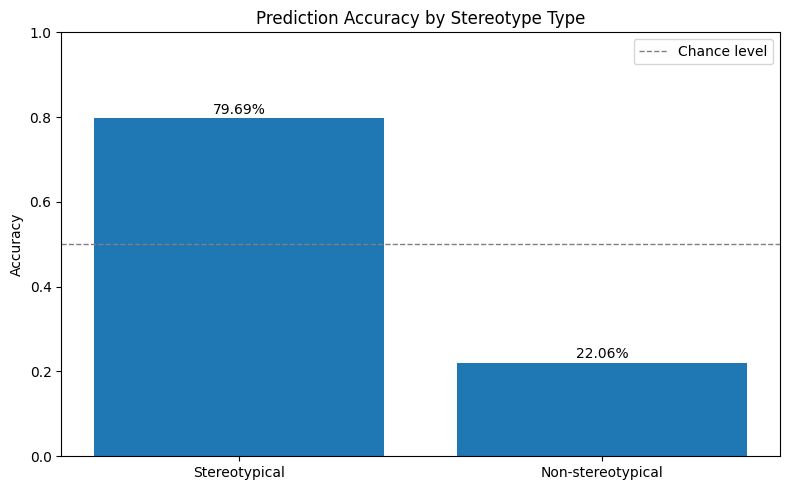

In [178]:
import matplotlib.pyplot as plt

# Accuracy values
accuracies = [stereotypical_accuracy, non_stereotypical_accuracy]
labels = ['Stereotypical', 'Non-stereotypical']

# Bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2%}', ha='center')

# Styling
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy by Stereotype Type')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance level')
plt.legend()
#plt.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Plotting the professions on the svm-derived gender axis for neutral sentences

This way, we can see whether the variant of the profession (female or male) are inherently more gendered, showing that maybe for example male is the default

In [ ]:
# Copy word_projection_df
df = word_projection_df.copy()

# Create a column for absolute projection (bias magnitude)
df['abs_projection'] = df['word_projection'].abs()

# Group by profession_variant and take the mean of the magnitudes
bias_per_gender = df.groupby('profession_variant')['abs_projection'].mean()

print(bias_per_gender)

profession_variant
0    1.928624
1    0.925527
Name: abs_projection, dtype: float64


Final model loaded.


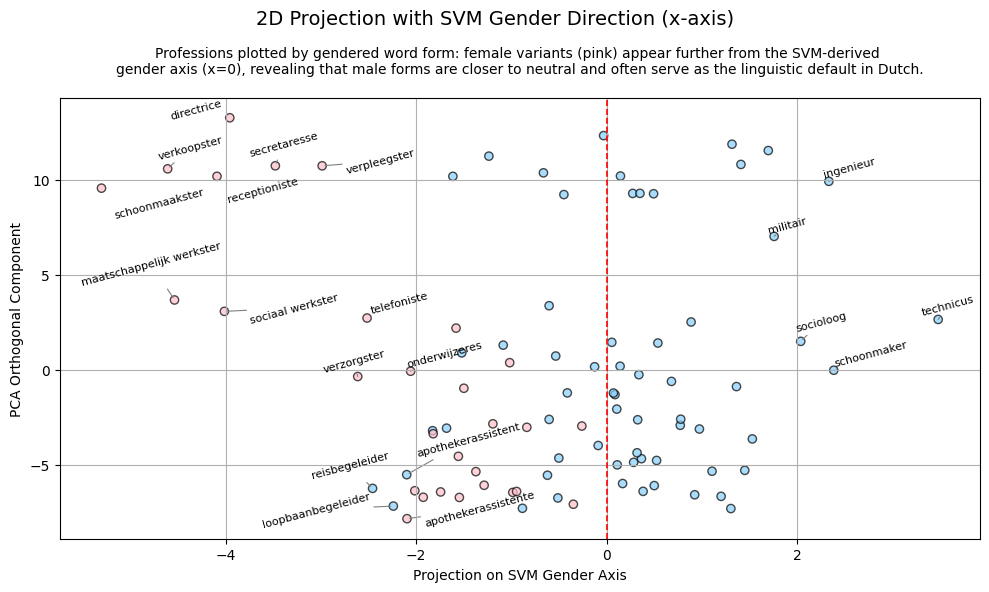

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.decomposition import PCA
from adjustText import adjust_text

# Load final model
final_model_path = "svm_models_checkpoint100_BERT/svm_final_model.joblib"
final_model = joblib.load(final_model_path)
weight_vector = final_model.coef_[0]
print("Final model loaded.")

# Load in sentences and embeddings
embeddings_neutral = np.load("../out/profession_embeddings_neutral.npy")
labels_neutral = np.load("../out/profession_labels_neutral.npy")
sentences_neutral = np.load("../out/profession_sentences_neutral.npy")
gender_labels_neutral = np.load("../out/profession_gender_labels_neutral.npy", allow_pickle=True)
gender_bias_neutral = np.load("../out/profession_gender_bias_neutral.npy", allow_pickle=True)
profession_variants_neutral = np.load("../out/profession_profession_variants_neutral.npy", allow_pickle=True)

# Filter sentences starting with "Het is een"
mask = np.array([s.startswith("Het is een") for s in sentences_neutral])

# Apply mask to all relevant arrays
embeddings = embeddings_neutral[mask]
labels = labels_neutral[mask]
sentences = sentences_neutral[mask]
gender_labels = gender_labels_neutral[mask]
gender_biases = gender_bias_neutral[mask]
profession_variants = profession_variants_neutral[mask]

sentences = np.array([s.replace("Het is een ", "", 1) for s in sentences])

# Normalize SVM direction
gender_axis = weight_vector / np.linalg.norm(weight_vector)

projections = embeddings @ gender_axis
residuals = embeddings - np.outer(projections, gender_axis)

# Now use PCA on residuals to find the main orthogonal direction
pca = PCA(n_components=1)
orthogonal_axis = pca.fit_transform(residuals).flatten()

# Combine projections and orthogonal axis
X_2d = np.vstack([projections, orthogonal_axis]).T

# Create plot
plt.figure(figsize=(10, 6))
colors = [
    'pink' if profession_variant == 0
    else 'lightskyblue' if profession_variant == 1
    else 'yellow' 
    for profession_variant in profession_variants
]

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.7, edgecolor='k')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.2)  # Decision boundary

plt.suptitle("2D Projection with SVM Gender Direction (x-axis)", fontsize=14)
plt.title("Professions plotted by gendered word form: female variants (pink) appear further from the SVM-derived \ngender axis (x=0), revealing that male forms are closer to neutral and often serve as the linguistic default in Dutch.\n", fontsize=10)
plt.xlabel("Projection on SVM Gender Axis")
plt.ylabel("PCA Orthogonal Component")
plt.grid(True)

# Annotate a few extreme points
sorted_indices = np.argsort(X_2d[:, 0])

# Collect all annotations first
texts = []
#for i in list(sorted_indices[:15]) + list(sorted_indices[-15:]):
for i in list(sorted_indices[:15]) + list(sorted_indices[-5:]):
    texts.append(
        plt.text(X_2d[i, 0], X_2d[i, 1], sentences[i],
                 fontsize=8, ha='center', rotation=15)
    )

# Adjust to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

plt.tight_layout()
plt.show()
